# Interactive plot for the functions:
$\Large f(x) = \frac{3x^2 - 9}{x^3}$

$\Large g_p(x) = px^2$

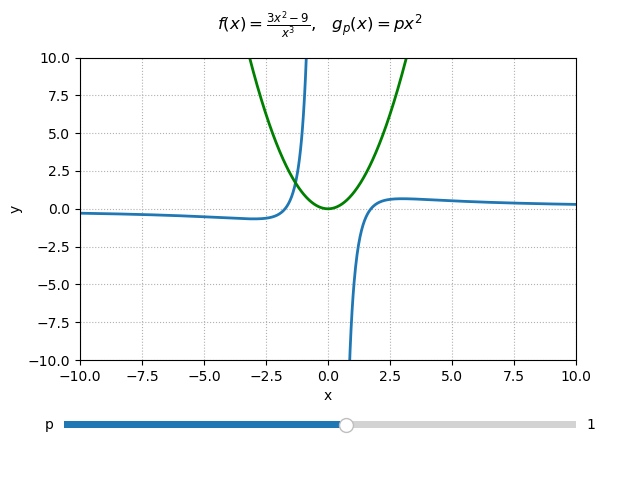

In [6]:
# IPython magic command for enabling interactive matplotlib plots in Jupyter
# notebook (disable when executing this code with a regular Python
# interpreter).
%matplotlib widget

# Imports
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt
import numpy as np

# Parameter `x` has a static range
x = np.linspace(-10, 10, 1000)

# Parameter `p` is taken from slider with limits as defined here
p_init = 1
p_min = -10
p_max = 10

# Range of `y` values for function `f` is calculated from `x` parameter
def func_f(x):
    return (3 * x ** 2 - 9) / (x ** 3)

# Range of `y` values for function `g` is calculated from `x` and `p` parameters
def func_g(x, p):
    return p * x ** 2

# Latex string representation of `f_func` and `g_func`
y_str = "$f(x) = \\frac{3x^2 - 9}{x^3}$,   $g_p(x) = px^2$"

# Find limits for `y`
# y_range_1 = func_g(x, p_min)
# y_range_2 = func_g(x, p_max)
# y_min = min(min(y_range_1), min(y_range_2))
# y_max = max(max(y_range_1), max(y_range_2))
y_min = -10
y_max = 10

# Set axes limits
xlim = (min(x), max(x))
ylim = (y_min, y_max)

# Initialize figure with axes
fig = plt.figure()
axes = plt.axes(
    xlim=xlim,
    ylim=ylim,
)
axes.grid(linestyle="dotted")
axes.set_xlabel("x")
axes.set_ylabel("y")

# Print equation of plotted function above axes
fig.suptitle(y_str)

# Expand figure window to make room for slider
fig.subplots_adjust(bottom=0.25)

# Add slider for parameter `p`
slider_axes = fig.add_axes([0.1, 0.1, 0.8, 0.03])
slider = Slider(
    ax=slider_axes,
    label='p',
    valmin=p_min,
    valmax=p_max,
    valinit=p_init,
)

# Initialize lines
yf_init = func_f(x)
yf_init = np.ma.masked_where(np.abs(yf_init) > 100.0, yf_init)
line_f, = axes.plot(x, yf_init, lw = 2)
yg_init = func_g(x, p_init)
line_g, = axes.plot(x, yg_init, lw = 2, color="g")

# Function for redrawing plot for new `p` value
def update(p):
    p = slider.val
    yf = func_f(x)
    yf = np.ma.masked_where(np.abs(yf) > 100.0, yf)
    yg = func_g(x, p)
    line_f.set_ydata(yf)
    line_g.set_ydata(yg)
    fig.canvas.draw_idle()

# Link slider to plot update function
slider.on_changed(update)

# Show plot
plt.show()